In [1]:
"""
In dit project haal ik een phenotype uit https://aragwas.1001genomes.org/#/
Ik link dit aan het genotype van arabidopsis thialiana (gevonden in https://aragwas.1001genomes.org/#/)
"""

'\nIn dit project haal ik een phenotype uit https://aragwas.1001genomes.org/#/\nIk link dit aan het genotype van arabidopsis thialiana (gevonden in https://aragwas.1001genomes.org/#/)\n'

In [2]:
import h5py
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import statsmodels.api as sm
import limix
print(limix.__version__)


pheno = pd.read_csv("Data/plant_dry_weight.csv")

print(pheno.head())

C:\Users\jandr\anaconda3\envs\limix_win\lib\site-packages\limix\_cli\_cli.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


3.0.4
  phenotype_name  accession_id accession_name accession_cs_number  \
0      rosetteDM            88            CYR             CS76790   
1      rosetteDM           108         LDV-18             CS77013   
2      rosetteDM           139         LDV-46             CS77014   
3      rosetteDM           159         MAR2-3             CS77070   
4      rosetteDM           265          PYL-6             CS77198   

   accession_longitude  accession_latitude accession_country  phenotype_value  \
0             0.683333             47.4000            France          238.430   
1            -4.066670             48.5167            France          290.955   
2            -4.066670             48.5167            France          292.970   
3             3.933330             47.3500            France          416.055   
4            -1.166670             44.6500            France          123.505   

   obs_unit_id  
0        17709  
1        17710  
2        17711  
3        17712  
4      

In [3]:
pheno = pheno[['accession_id', 'phenotype_value']]
print(pheno.head())

   accession_id  phenotype_value
0            88          238.430
1           108          290.955
2           139          292.970
3           159          416.055
4           265          123.505


In [4]:
file_path = "Data/genotype.hdf5"

with h5py.File(file_path, "r") as f:
    print("Keys in file:")
    print(list(f.keys()))

Keys in file:
['accessions', 'positions', 'snps']


In [5]:
with h5py.File(file_path, "r") as f:
    for key in f.keys():
        print(key, f[key])

accessions <HDF5 dataset "accessions": shape (2029,), type "|S6">
positions <HDF5 dataset "positions": shape (10709466,), type "<i4">
snps <HDF5 dataset "snps": shape (10709466, 2029), type "|i1">


In [6]:
with h5py.File("Data/genotype.hdf5", "r") as f:
    accessions = [a.decode() for a in f["accessions"][:]]
    positions = f["positions"][:]
    
    # selecteer bijvoorbeeld eerste 50,000 SNPs
    snp_subset = f["snps"][:50000, :]

In [7]:
geno = pd.DataFrame(
    snp_subset.T, 
    index=accessions
)

In [8]:
print(geno.head())

     0      1      2      3      4      5      6      7      8      9      \
88       0      0      0      0      0      0      0      1      0      0   
108      0      0      0      0      0      0      0      1      0      0   
139      0      0      0      0      0      0      0      1      0      0   
159      0      0      0      0      0      0      0      0      0      0   
265      0      0      0      0      0      0      0      0      0      0   

     ...  49990  49991  49992  49993  49994  49995  49996  49997  49998  49999  
88   ...      0      0      0      0      0      0      0      0      0      0  
108  ...      0      0      0      0      0      0      0      0      0      0  
139  ...      0      0      0      0      0      0      0      0      0      0  
159  ...      0      0      0      0      0      0      0      0      0      0  
265  ...      0      0      0      0      0      0      0      0      0      0  

[5 rows x 50000 columns]


In [9]:
# Zet phenotype index op accession_name
pheno = pheno.set_index("accession_id")
print(pheno.index[:5])
print(geno.index[:5])
pheno.index.duplicated().sum() #twee duplicates in pheno!


pheno.index = pheno.index.astype(int)
geno.index = geno.index.astype(int)
pheno = pheno[~pheno.index.duplicated(keep="first")]  #removed duplicates
print(pheno.index[:5])
print(geno.index[:5])


Int64Index([88, 108, 139, 159, 265], dtype='int64', name='accession_id')
Index(['88', '108', '139', '159', '265'], dtype='object')
Int64Index([88, 108, 139, 159, 265], dtype='int64', name='accession_id')
Int64Index([88, 108, 139, 159, 265], dtype='int64')


In [10]:
# Neem alleen overlappende accessions
common = pheno.index.intersection(geno.index)
print("Aantal overlap:", len(common))

# Sorteer de IDs zodat beide datasets exact dezelfde volgorde hebben
common = common.sort_values()

# Subset beide datasets
pheno = pheno.loc[common]
geno = geno.loc[common]

print("common:", common.shape)
print("pheno:", pheno.shape)
print("geno:", geno.shape)

Aantal overlap: 420
common: (420,)
pheno: (420, 1)
geno: (420, 50000)


In [11]:
print(pheno.index[:10])
print(geno.index[:10])

Int64Index([88, 108, 139, 159, 265, 410, 428, 430, 763, 765], dtype='int64')
Int64Index([88, 108, 139, 159, 265, 410, 428, 430, 763, 765], dtype='int64')


In [12]:
"""
Interpretatie:

Je phenotype file bevat 422 accessions

Je genotype subset bevat 2029 accessions totaal, maar

Slechts 420 komen in beide voor (zijn accessories met zowel een phenotype en een genotype)

Dus:

👉 2 phenotype accessions hebben géén genotype
👉 1609 genotype accessions hebben géén phenotype

Dit is volledig normaal bij Arabidopsis datasets.
"""

'\nInterpretatie:\n\nJe phenotype file bevat 422 accessions\n\nJe genotype subset bevat 2029 accessions totaal, maar\n\nSlechts 420 komen in beide voor (zijn accessories met zowel een phenotype en een genotype)\n\nDus:\n\n👉 2 phenotype accessions hebben géén genotype\n👉 1609 genotype accessions hebben géén phenotype\n\nDit is volledig normaal bij Arabidopsis datasets.\n'

In [13]:
# Vul eventueel missing data met NaN
geno = geno.replace(-1, np.nan)  # afhankelijk van je HDF5 encoding

# Missingness filter: verwijder SNPs met >10% missing
geno = geno.loc[:, geno.isna().mean() < 0.1]

In [14]:
# MAF filter: verwijder SNPs met MAF < 0.05

#geno.mean = gemiddelde genotypische waarde per SNP -> delen door 2 geeft frequentie van het alternatieve allel
allele_freq = geno.mean(axis=0) / 2  # 0,1,2 encoding → freq alt allele

#allele_freq is frequentie van alternatieve allel, 1-allele_freq is frequentie van referentie allel
#minimum van beide is Minor Allele Frequency (MAF)
maf = np.minimum(allele_freq, 1 - allele_freq)

#filter op MAF ≥ 0.05
geno = geno.loc[:, maf > 0.05]

In [15]:
print("Aantal SNPs na filtering:", geno.shape[1])

Aantal SNPs na filtering: 5568


     7      43     63     79     85     90     91     121    131    140    \
88       1      0      0      1      1      0      1      0      1      0   
108      1      0      0      0      0      0      1      0      0      0   
139      1      0      0      0      0      0      1      0      0      0   
159      0      0      0      0      0      0      0      0      0      0   
265      0      0      1      0      0      1      1      1      1      1   

     ...  49915  49932  49936  49973  49974  49975  49976  49977  49982  49995  
88   ...      0      0      1      1      1      1      1      1      1      0  
108  ...      0      1      1      1      1      1      1      1      1      0  
139  ...      0      0      1      1      1      1      1      1      1      0  
159  ...      0      0      1      1      1      1      1      1      1      0  
265  ...      0      0      1      1      1      1      1      1      1      0  

[5 rows x 5568 columns]
          PC1        PC2  

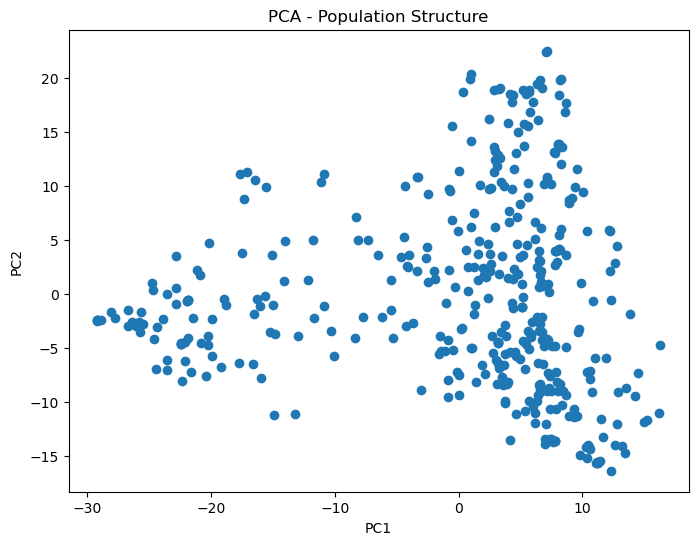

In [16]:
# Vul missing values voor PCA
geno_filled = geno.fillna(geno.mean())
print(geno_filled.head())

# PCA uitvoeren
pca = PCA(n_components=10) #5 PC's although we only plot first 10 PCs
pcs = pca.fit_transform(geno_filled)

# DataFrame met PC scores
pcs_df = pd.DataFrame(pcs, index=geno.index, columns=[f'PC{i+1}' for i in range(pcs.shape[1])])
print(pcs_df.head())

# Voeg PC1 tot PC10 toe aan phenotype dataframe
pheno = pheno.join(pcs_df)

# Plot PCA (PC1 vs PC2)
plt.figure(figsize=(8,6))
plt.scatter(pheno['PC1'], pheno['PC2'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Population Structure')
plt.show()

In [17]:
print(pheno.head())

     phenotype_value       PC1        PC2       PC3       PC4       PC5  \
88           238.430  8.101170  18.466258 -1.508145 -2.562853  2.679776   
108          290.955  7.754895  13.042208 -1.493745 -0.620501  0.602850   
139          292.970  7.679218  13.189680 -1.522427 -0.540452  0.451218   
159          416.055  4.800679  14.967993  0.733257  4.812925  1.615867   
265          123.505  6.298438  -2.132021  9.286238 -0.157873 -0.353736   

          PC6       PC7       PC8       PC9      PC10  
88  -5.680900  5.400114  3.229896  5.065112  3.674420  
108 -8.238373 -2.999365 -2.332787  0.320399 -9.059535  
139 -8.245680 -2.946076 -2.349206  0.300675 -8.940538  
159 -3.594950 -3.094512  1.674938  3.107525  0.617106  
265 -2.159918 -3.538871  3.881910 -5.295905 -0.033313  


PC1 explains 12.57% of total variance
PC2 explains 7.92% of total variance
PC3 explains 5.40% of total variance
PC4 explains 4.26% of total variance
PC5 explains 3.75% of total variance
PC6 explains 3.01% of total variance
PC7 explains 2.62% of total variance
PC8 explains 2.41% of total variance
PC9 explains 2.23% of total variance
PC10 explains 2.19% of total variance


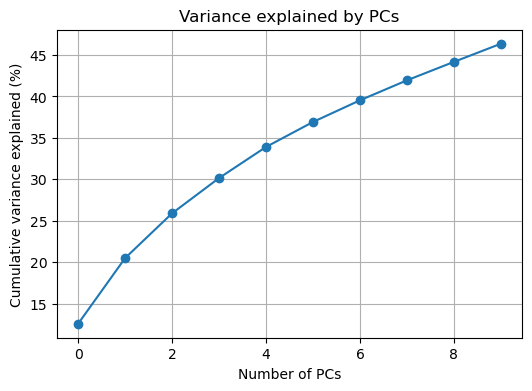

In [18]:
#Check variance explained by each PC
explained_var = pca.explained_variance_ratio_
for i, var in enumerate(explained_var):
    print(f"PC{i+1} explains {var*100:.2f}% of total variance")

# Optioneel: cumulative variance plot
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(explained_var)*100, marker='o')
plt.xlabel('Number of PCs')
plt.ylabel('Cumulative variance explained (%)')
plt.title('Variance explained by PCs')
plt.grid(True)
plt.show()

In [19]:
"""
is there not a lot of variation lost by doing PCA?
You have tens of thousands of SNPs (~50k in your subset). In genomics, it’s common for the first 2–5 PCs to explain 20–40% of variance. 
GWAS pipelines usually don’t need to capture 100% of variance.
Goal of PCs in GWAS: not to explain all variance, but to capture population structure / ancestry to avoid false positives.
The remaining ~65% of SNP variance is mostly random variation, technical noise, or very subtle structure, which GWAS will deal with via residuals.
"""

'\nis there not a lot of variation lost by doing PCA?\nYou have tens of thousands of SNPs (~50k in your subset). In genomics, it’s common for the first 2–5 PCs to explain 20–40% of variance. \nGWAS pipelines usually don’t need to capture 100% of variance.\nGoal of PCs in GWAS: not to explain all variance, but to capture population structure / ancestry to avoid false positives.\nThe remaining ~65% of SNP variance is mostly random variation, technical noise, or very subtle structure, which GWAS will deal with via residuals.\n'

In [20]:
print(geno.head())
print(geno.shape)
print(pheno.shape)

     7      43     63     79     85     90     91     121    131    140    \
88       1      0      0      1      1      0      1      0      1      0   
108      1      0      0      0      0      0      1      0      0      0   
139      1      0      0      0      0      0      1      0      0      0   
159      0      0      0      0      0      0      0      0      0      0   
265      0      0      1      0      0      1      1      1      1      1   

     ...  49915  49932  49936  49973  49974  49975  49976  49977  49982  49995  
88   ...      0      0      1      1      1      1      1      1      1      0  
108  ...      0      1      1      1      1      1      1      1      1      0  
139  ...      0      0      1      1      1      1      1      1      1      0  
159  ...      0      0      1      1      1      1      1      1      1      0  
265  ...      0      0      1      1      1      1      1      1      1      0  

[5 rows x 5568 columns]
(420, 5568)
(420, 11)


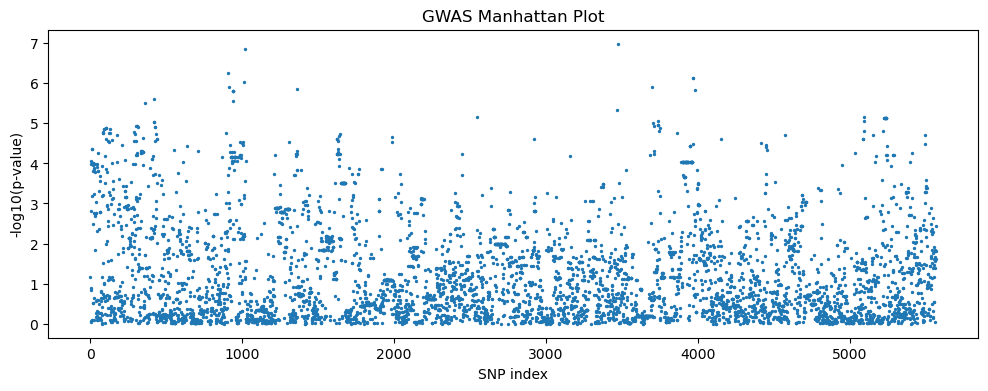

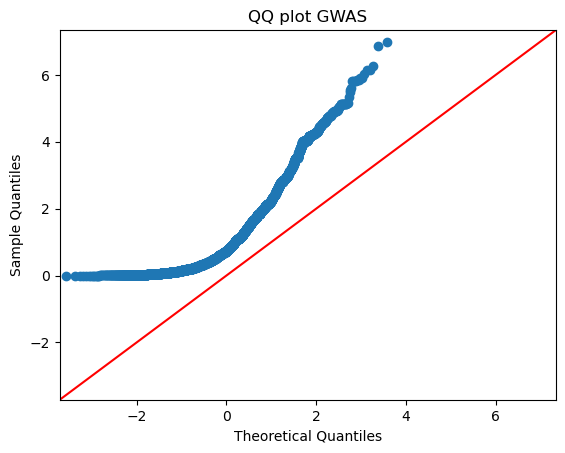

In [21]:
phenotype_col = 'phenotype_value'
p_values = []

for snp in geno.columns:
    X = pheno[['PC1','PC2']].copy()
    X[snp] = geno[snp]
    X = sm.add_constant(X)
    y = pheno[phenotype_col]
    
    try:
        model = sm.OLS(y, X).fit()
        p_values.append(model.pvalues[snp])
    except:
        p_values.append(np.nan)

# Manhattan plot
plt.figure(figsize=(12,4))
plt.scatter(range(len(p_values)), -np.log10(p_values), s=2)
plt.xlabel('SNP index')
plt.ylabel('-log10(p-value)')
plt.title('GWAS Manhattan Plot')
plt.show()

# QQ plot
from statsmodels.graphics.gofplots import qqplot
qqplot(-np.log10([p for p in p_values if not np.isnan(p)]), line='45')
plt.title('QQ plot GWAS')
plt.show()

In [22]:
"""
clearly inflated because alll points are above the diagonal 
"""

'\nclearly inflated because alll points are above the diagonal \n'

In [23]:
from scipy.stats import chi2
import numpy as np

# Remove nan p-values
pvals_clean = np.array(p_values)
pvals_clean = pvals_clean[~np.isnan(pvals_clean)]

# Convert p-values to chi-square statistics
chi2_stats = chi2.ppf(1 - pvals_clean, df=1)

# Calculate lambda
lambda_gc = np.median(chi2_stats) / 0.456

print("Genomic inflation factor (lambda):", lambda_gc)

Genomic inflation factor (lambda): 3.8256404445482035


In [24]:
"""
lambda is 3.96 -> way too high -> add more PCs
"""

'\nlambda is 3.96 -> way too high -> add more PCs\n'

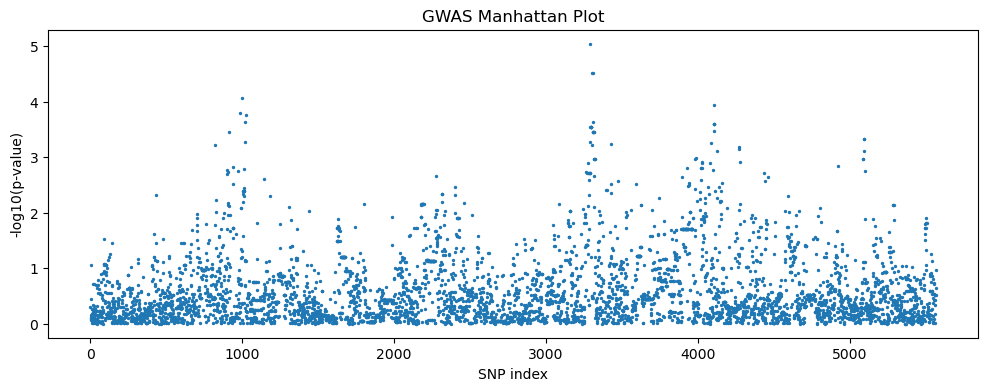

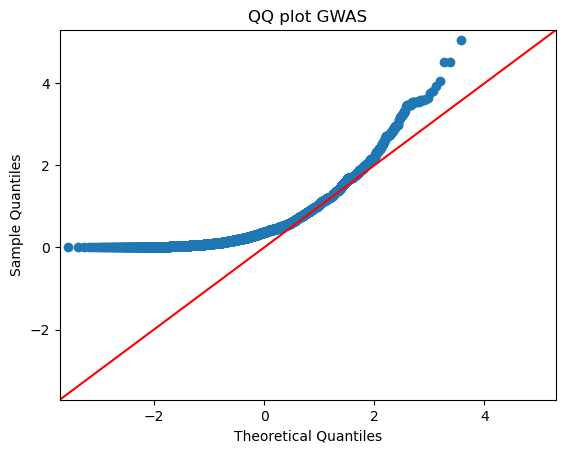

In [25]:
phenotype_col = 'phenotype_value'
p_values = []

for snp in geno.columns:
    X = pheno[['PC1','PC2', 'PC3','PC4', 'PC5']].copy()
    X[snp] = geno[snp]
    X = sm.add_constant(X)
    y = pheno[phenotype_col]
    
    try:
        model = sm.OLS(y, X).fit()
        p_values.append(model.pvalues[snp])
    except:
        p_values.append(np.nan)

# Manhattan plot
plt.figure(figsize=(12,4))
plt.scatter(range(len(p_values)), -np.log10(p_values), s=2)
plt.xlabel('SNP index')
plt.ylabel('-log10(p-value)')
plt.title('GWAS Manhattan Plot')
plt.show()

# QQ plot
from statsmodels.graphics.gofplots import qqplot
qqplot(-np.log10([p for p in p_values if not np.isnan(p)]), line='45')
plt.title('QQ plot GWAS')
plt.show()

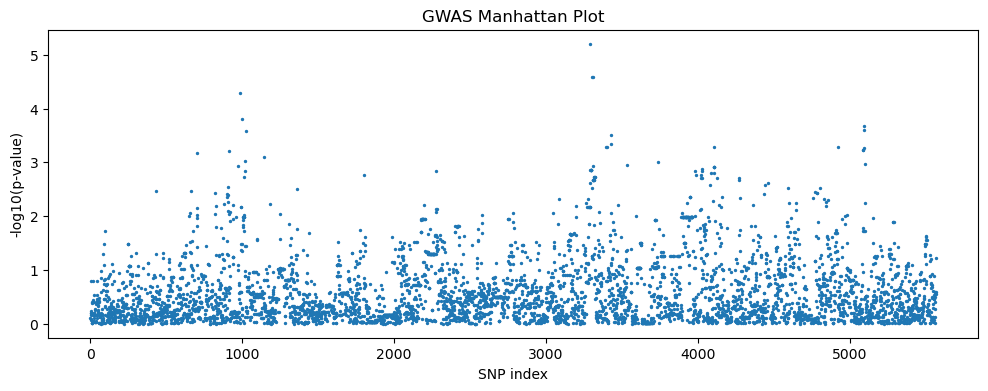

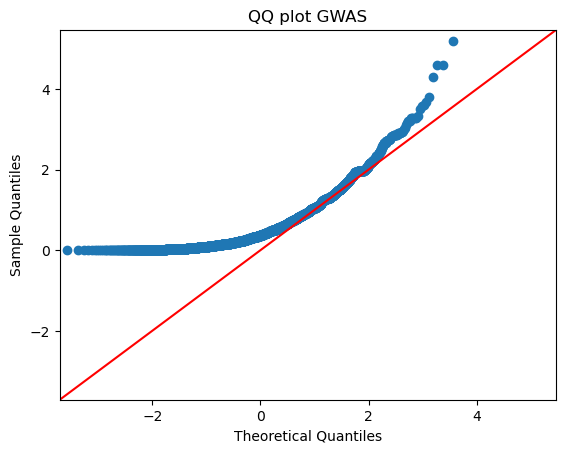

In [26]:
phenotype_col = 'phenotype_value'
p_values = []

for snp in geno.columns:
    X = pheno[['PC1','PC2', 'PC3','PC4', 'PC5', 'PC6','PC7', 'PC8','PC9', 'PC10']].copy()
    X[snp] = geno[snp]
    X = sm.add_constant(X)
    y = pheno[phenotype_col]
    
    try:
        model = sm.OLS(y, X).fit()
        p_values.append(model.pvalues[snp])
    except:
        p_values.append(np.nan)

# Manhattan plot
plt.figure(figsize=(12,4))
plt.scatter(range(len(p_values)), -np.log10(p_values), s=2)
plt.xlabel('SNP index')
plt.ylabel('-log10(p-value)')
plt.title('GWAS Manhattan Plot')
plt.show()

# QQ plot
from statsmodels.graphics.gofplots import qqplot
qqplot(-np.log10([p for p in p_values if not np.isnan(p)]), line='45')
plt.title('QQ plot GWAS')
plt.show()

In [27]:
"""You’ve just observed something very important:

Adding PCs reduces inflation a bit, but not enough.

That tells us:
Population structure ≠ only 2–10 ancestry axes
There is cryptic relatedness between lines
OLS assumptions are violated because it asumes all plants are statistically independent, but in Arabidopsis:
Some lines share recent ancestry
Some are geographically clustered
Some may be nearly identical

This correlation creates systematic p-value inflation.

example:
50 Swedish accessions are closely related
They are all small
They share many SNPs
OLS thinks:
"Wow! All these SNPs correlate with small size!"
But actually it’s shared ancestry, not causal effect.

Now we fix that properly using Mixed Linear Models (MLM).
"""

'You’ve just observed something very important:\n\nAdding PCs reduces inflation a bit, but not enough.\n\nThat tells us:\nPopulation structure ≠ only 2–10 ancestry axes\nThere is cryptic relatedness between lines\nOLS assumptions are violated because it asumes all plants are statistically independent, but in Arabidopsis:\nSome lines share recent ancestry\nSome are geographically clustered\nSome may be nearly identical\n\nThis correlation creates systematic p-value inflation.\n\nexample:\n50 Swedish accessions are closely related\nThey are all small\nThey share many SNPs\nOLS thinks:\n"Wow! All these SNPs correlate with small size!"\nBut actually it’s shared ancestry, not causal effect.\n\nNow we fix that properly using Mixed Linear Models (MLM).\n'

In [28]:
phenotype_col = 'phenotype_value'
p_values = []


In [29]:
"""
#step 1: standardize genotypes -> alleles have different frequencies -> make alleles comparable 
geno_std = (geno - geno.mean()) / geno.std()
geno_std = geno_std.fillna(0)

#step 2: compute kinship matrix
K = np.dot(geno_std, geno_std.T) / geno_std.shape[1]
#K is 420 × 420 and K[i,j] measures relatedness between plant i and j

#step 3: Fit Mixed Model Per SNP
p_values_mixed = []

for snp in geno.columns:
    
    X = pheno[['PC1','PC2','PC3','PC4','PC5']].copy()
    X[snp] = geno[snp]
    X = sm.add_constant(X)
    
    y = pheno[phenotype_col]
    
    try:
        model = sm.MixedLM(
            endog=y,
            exog=X,
            groups=pheno.index,
            exog_re=None,
            use_sqrt=True
        )
        
        result = model.fit(reml=False)
        p_values_mixed.append(result.pvalues[snp])
        
    except:
        p_values_mixed.append(np.nan)
"""

"\n#step 1: standardize genotypes -> alleles have different frequencies -> make alleles comparable \ngeno_std = (geno - geno.mean()) / geno.std()\ngeno_std = geno_std.fillna(0)\n\n#step 2: compute kinship matrix\nK = np.dot(geno_std, geno_std.T) / geno_std.shape[1]\n#K is 420 × 420 and K[i,j] measures relatedness between plant i and j\n\n#step 3: Fit Mixed Model Per SNP\np_values_mixed = []\n\nfor snp in geno.columns:\n    \n    X = pheno[['PC1','PC2','PC3','PC4','PC5']].copy()\n    X[snp] = geno[snp]\n    X = sm.add_constant(X)\n    \n    y = pheno[phenotype_col]\n    \n    try:\n        model = sm.MixedLM(\n            endog=y,\n            exog=X,\n            groups=pheno.index,\n            exog_re=None,\n            use_sqrt=True\n        )\n        \n        result = model.fit(reml=False)\n        p_values_mixed.append(result.pvalues[snp])\n        \n    except:\n        p_values_mixed.append(np.nan)\n"

In [30]:
#let's use the limix library for Mixed Linear Model

#prepare the data
# phenotype vector
y = pheno[phenotype_col].values


# genotype matrix
G = geno.values

In [31]:
print(y[0:5,])
print(G[0:5, 0:5])

[238.43  290.955 292.97  416.055 123.505]
[[1 0 0 1 1]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]]


In [32]:
from limix.stats import linear_kinship

K = linear_kinship(G)

Kinship: 100%|███████████████████████████████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 629.56it/s]


In [33]:
y = y.reshape(-1,1)

In [34]:
# covariates (PCs)
PCs = pheno[[f'PC{i}' for i in range(1,6)]].values
covs = np.column_stack([
    np.ones(len(y)),  # intercept
    PCs
])

print(covs[0:5, 0:5])

[[ 1.          8.10116965 18.46625837 -1.50814456 -2.56285318]
 [ 1.          7.75489525 13.04220826 -1.49374497 -0.62050091]
 [ 1.          7.6792178  13.18968004 -1.52242724 -0.5404517 ]
 [ 1.          4.80067856 14.96799343  0.73325739  4.81292497]
 [ 1.          6.29843814 -2.13202097  9.28623805 -0.1578732 ]]


In [35]:
print(G.shape)      # SNP matrix (samples × SNPs)
print(y.shape)      # phenotype (samples × 1)
print(K.shape)      # kinship (samples × samples)
print(covs.shape)   # covariates (samples × covariates)

(420, 5568)
(420, 1)
(420, 420)
(420, 6)


In [36]:
print(pd.__version__)

1.5.3


In [37]:
import sys
import types
import pandas as pd

# create a fake module 'pandas.core.index'
mod = types.SimpleNamespace()

# use the public InvalidIndexError from pandas.errors
from pandas.errors import InvalidIndexError
mod.InvalidIndexError = InvalidIndexError

# insert it into sys.modules so Python uses it whenever something does
# 'from pandas.core.index import InvalidIndexError'
sys.modules['pandas.core.index'] = mod

# Now import LIMIX
from limix.qtl import scan


In [38]:
result = scan(
    G=G,
    Y=y,
    K=K,
    M=covs
)

pvals = result.stats["pv20"]

================================= QTL analysis starts ==================================

Normalising input... 
done (1.49 seconds).

Input
-----

Likelihood       : normal
Traits (1)       : [0]
Covariates (6)   : [0, 1, 2, ..., 5]
Variants 5568    : [0, 1, 2, ..., 5567]
N. of candidates : 5568
Kinship          : present



LMM: 28it [00:00, 176.45it/s]
Results: 100%|███████████████████████████████████████████████████████████████████████████████| 5568/5568 [00:00<00:00, 14724.56it/s]



Hypothesis 0
------------

𝐲 ~ 𝓝(𝙼𝜶, 53710.417⋅𝙺 + 263539.649⋅𝙸)

M     = ['0' '1' '2' '3' '4' '5']
𝜶     = [635.0740119    6.7278255  -13.24853817  22.41154194  -1.2835843    3.53434288]
se(𝜶) = [25.04945814  7.34929247  7.70626194  8.29823668  8.3805461   8.27395474]
lml   = -3243.3994017788154

Hypothesis 2
------------

𝐲 ~ 𝓝(𝙼𝜶 + G𝛃, s(53710.417⋅𝙺 + 263539.649⋅𝙸))

          lml       cov. effsizes   cand. effsizes
--------------------------------------------------
mean   -3.243e+03       1.083e+02        6.342e+00
std     7.817e-01       2.352e+02        1.043e+02
min    -3.243e+03      -2.439e+01       -4.792e+02
25%    -3.243e+03      -1.284e+00       -6.117e+01
50%    -3.243e+03       5.161e+00       -1.751e+00
75%    -3.243e+03       2.243e+01        6.521e+01
max    -3.235e+03       1.106e+03        3.892e+02

Likelihood-ratio test p-values
------------------------------

       𝓗₀ vs 𝓗₂ 
----------------
mean   4.994e-01
std    2.975e-01
min    4.724e-05
25%    2.373e-01
5

========================== QTL analysis ends in 8.11 seconds ===========================